In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

sns.set_theme(style="whitegrid")

In [3]:
class Dataset:

    def __init__(self, filepath):
        self.filepath = filepath
        self.df = None

    def load(self):
        self.df = pd.read_csv(self.filepath)
        print("Shape :", self.df.shape)
        return self.df

    def head(self, n=5):
        return self.df.head(n)

    def info(self):
        return self.df.info()

    def missing_values(self):
        return self.df.isnull().sum()

    def churn_distribution(self):
        return (
            self.df["Exited"].value_counts(normalize=True)* 100
        )

In [4]:
class Preprocessor:

    def __init__(self, df):

        self.df = df.copy()

        self.X = None
        self.y = None

        self.X_train = None
        self.X_test = None

        self.y_train = None
        self.y_test = None

        self.scaler = None

        self.X_train_scaled = None
        self.X_test_scaled = None

    def clean_data(self):

        self.df = self.df.drop(
            columns=[
                "RowNumber",
                "CustomerId",
                "Surname",
            ]
        )

        self.df = pd.get_dummies(
            self.df,
            columns=[
                "Geography",
                "Gender"
            ],
            drop_first=True
        )

        for col in self.df.columns:

            if self.df[col].dtype == bool:

                self.df[col] = (
                    self.df[col]
                    .astype(int)
                )

        return self.df

    def split(self):

        self.X = self.df.drop(
            "Exited",
            axis=1
        )

        self.y = self.df["Exited"]

        (
            self.X_train,
            self.X_test,
            self.y_train,
            self.y_test
        ) = train_test_split(
            self.X,
            self.y,
            test_size=0.20,
            random_state=42,
            stratify=self.y
        )

        return (
            self.X_train,
            self.X_test,
            self.y_train,
            self.y_test
        )

    def scale(self):

        self.scaler = StandardScaler()

        self.X_train_scaled = (
            self.scaler.fit_transform(
                self.X_train
            )
        )

        self.X_test_scaled = (
            self.scaler.transform(
                self.X_test
            )
        )

        return (
            self.X_train_scaled,
            self.X_test_scaled
        )

In [5]:
class LogisticRegressionModel:

    def __init__(self):

        self.model = LogisticRegression(
            random_state=42,
            max_iter=1000
        )

        self.y_pred = None
        self.y_prob = None
        self.z_score = None

    def fit(self, X_train, y_train):
        self.model.fit(X_train, y_train)
        return self

    def predict(
        self,
        X_test
    ):

        self.y_pred = (
            self.model.predict(X_test)
        )

        self.y_prob = (
            self.model.predict_proba(X_test)
            [:,1]
        )

        self.z_score = (
            self.model.decision_function(
                X_test
            )
        )

        return (
            self.y_pred,
            self.y_prob,
            self.z_score
        )

    def coefficients(self, feature_names):
        coef_df = pd.DataFrame({
            "Feature": feature_names,
            "Coefficient":
            self.model.coef_[0]
        })

        return coef_df.sort_values(
            by="Coefficient",
            ascending=False
        )

    def odds_ratio(
        self,
        feature_names
    ):

        odds_df = pd.DataFrame({
            "Feature": feature_names,
            "Odds Ratio":
            np.exp(
                self.model.coef_[0]
            )
        })

        return odds_df.sort_values(
            by="Odds Ratio",
            ascending=False
        )

    def intercept(self):

        return self.model.intercept_[0]

In [6]:
class Evaluation:

    @staticmethod
    def metrics(
        y_true,
        y_pred
    ):

        return pd.DataFrame({

            "Metric": [
                "Accuracy",
                "Precision",
                "Recall",
                "F1 Score"
            ],

            "Value": [
                accuracy_score(y_true, y_pred),
                precision_score(y_true, y_pred),
                recall_score(y_true, y_pred),
                f1_score(y_true, y_pred)
            ]
        })

    @staticmethod
    def report(
        y_true,
        y_pred
    ):

        return classification_report(
            y_true,
            y_pred
        )

    @staticmethod
    def confusion(
        y_true,
        y_pred
    ):

        return confusion_matrix(
            y_true,
            y_pred
        )

In [7]:
class Visualization:

    @staticmethod
    def show_all(
        df,
        z_score,
        y_prob,
        y_test,
        cm,
        coef_df
    ):

        plt.figure(figsize=(6,4))
        sns.countplot(x=df["Exited"])
        plt.title("Distribusi Customer Churn")
        plt.show()


        z = np.linspace(-10,10,1000)
        sigmoid = 1/(1+np.exp(-z))

        plt.figure(figsize=(8,5))
        plt.plot(z,sigmoid)
        plt.title("Sigmoid Function")
        plt.show()

        plt.figure(figsize=(5,5))
        plt.scatter(
            z_score,
            y_prob,
            alpha=0.4
        )
        plt.title(
            "Sigmoid Transformation"
        )
        plt.show()

        # Confusion Matrix
        plt.figure(figsize=(6,5))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues"
        )
        plt.show()

        # Precision Recall Curve
        precision_curve, recall_curve, _ = (
            precision_recall_curve(
                y_test,
                y_prob
            )
        )

        plt.figure(figsize=(8,5))
        plt.plot(
            recall_curve,
            precision_curve
        )
        plt.show()

        # Coefficient Plot
        plt.figure(figsize=(10,6))
        sns.barplot(
            data=coef_df,
            x="Coefficient",
            y="Feature"
        )
        plt.show()

In [8]:
if __name__ == "__main__":

    data = Dataset(
        "Churn_Modelling.csv"
    )

    df = data.load()

    prep = Preprocessor(df)

    prep.clean_data()

    prep.split()

    model = LogisticRegressionModel()

    prep.scale()

    model.fit(
        prep.X_train_scaled,
        prep.y_train
    )

    (
        y_pred,
        y_prob,
        z_score
    ) = model.predict(
        prep.X_test_scaled
    )

    metrics_df = Evaluation.metrics(
        prep.y_test,
        y_pred,
    )

    report = Evaluation.report(
        prep.y_test,
        y_pred
    )

    cm = Evaluation.confusion(
        prep.y_test,
        y_pred
    )

    coef_df = model.coefficients(
        prep.X.columns
    )

    odds_df = model.odds_ratio(
        prep.X.columns
    )

    print(metrics_df)

    print(report)

    display(coef_df)

    display(odds_df)

Shape : (10000, 14)
      Metric     Value
0   Accuracy  0.808000
1  Precision  0.589147
2     Recall  0.186732
3   F1 Score  0.283582
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



,Feature,Coefficient
1,Age,0.738847
8,Geography_Germany,0.356679
3,Balance,0.160622
7,EstimatedSalary,0.047725
9,Geography_Spain,0.018907
2,Tenure,-0.020071
5,HasCrCard,-0.032208
4,NumOfProducts,-0.070292
0,CreditScore,-0.085986
10,Gender_Male,-0.260851


,Feature,Odds Ratio
1,Age,2.093520
8,Geography_Germany,1.428578
3,Balance,1.174241
7,EstimatedSalary,1.048882
9,Geography_Spain,1.019087
2,Tenure,0.980129
5,HasCrCard,0.968306
4,NumOfProducts,0.932122
0,CreditScore,0.917607
10,Gender_Male,0.770396


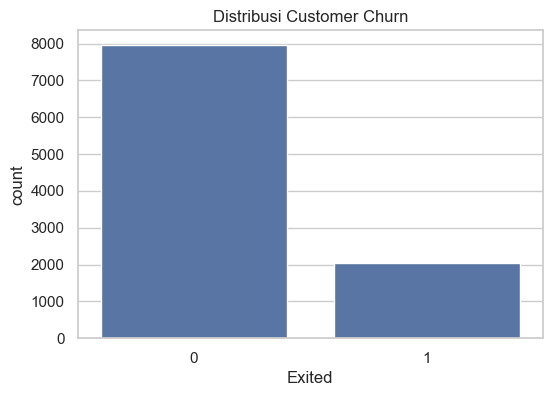

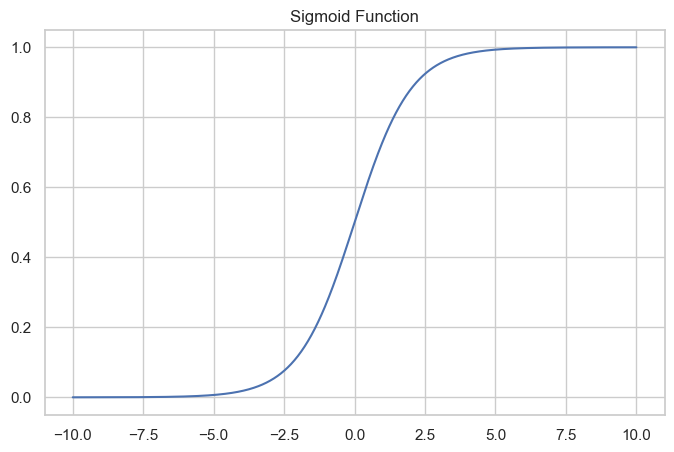

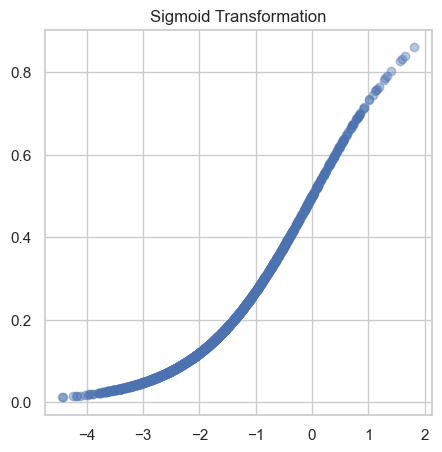

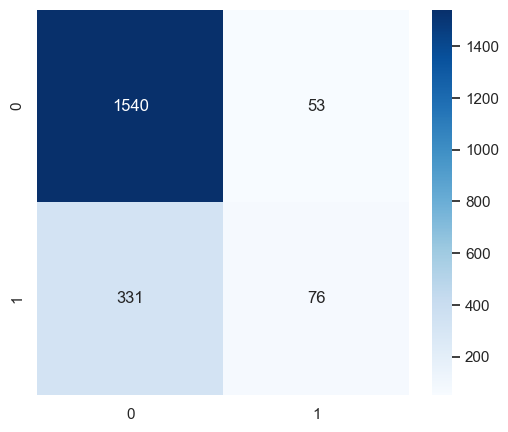

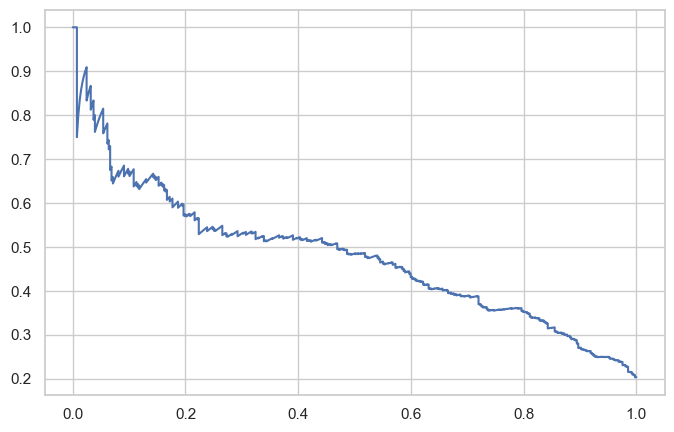

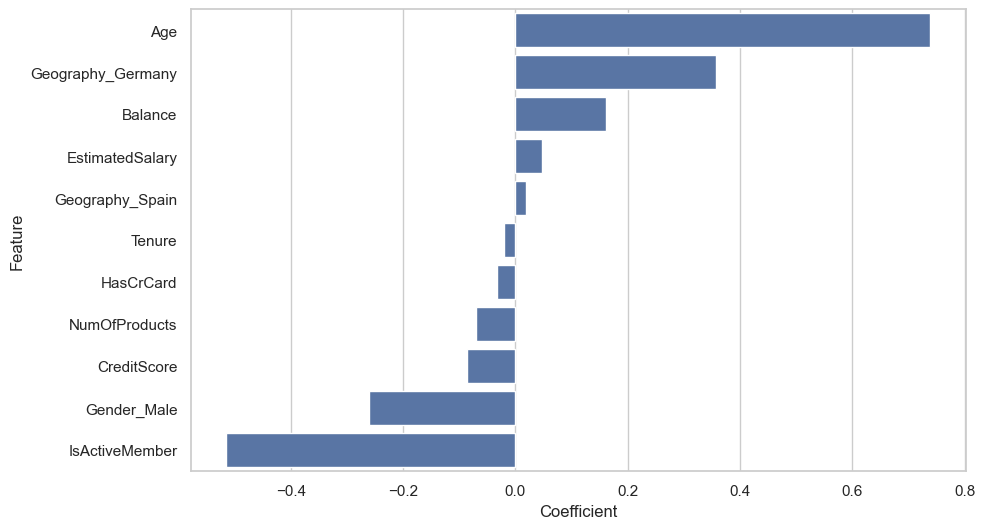

In [9]:
if __name__ == "__main__":

    Visualization.show_all(
        df,
        z_score,
        y_prob,
        prep.y_test,
        cm,
        coef_df
    )

In [10]:
from sklearn.utils import resample
import pandas as pd

test_df = prep.X_test.copy()
test_df["Exited"] = prep.y_test.values

test_0 = test_df[test_df["Exited"] == 0]
test_1 = test_df[test_df["Exited"] == 1]

test0 = resample(
    test_0,
    replace=False,
    n_samples=1000,
    random_state=42
)

test1 = resample(
    test_1,
    replace=True,
    n_samples=1000,
    random_state=42
)

balanced_test = pd.concat(
    [test0, test1],
    ignore_index=True
).sample(
    frac=1,
    random_state=42
)

X_test_balanced = balanced_test.drop("Exited", axis=1)
y_test_balanced = balanced_test["Exited"]

X_test_balanced_scaled = prep.scaler.transform(
    X_test_balanced
)

print(y_test_balanced.value_counts())

Exited
1    1000
0    1000
Name: count, dtype: int64


In [11]:
y_pred_balanced = model.model.predict(
    X_test_balanced_scaled
)

y_prob_balanced = model.model.predict_proba(
    X_test_balanced_scaled
)[:,1]

In [12]:
print(classification_report(
    y_test_balanced,
    y_pred_balanced
))

              precision    recall  f1-score   support

           0       0.55      0.96      0.70      1000
           1       0.85      0.20      0.32      1000

    accuracy                           0.58      2000
   macro avg       0.70      0.58      0.51      2000
weighted avg       0.70      0.58      0.51      2000



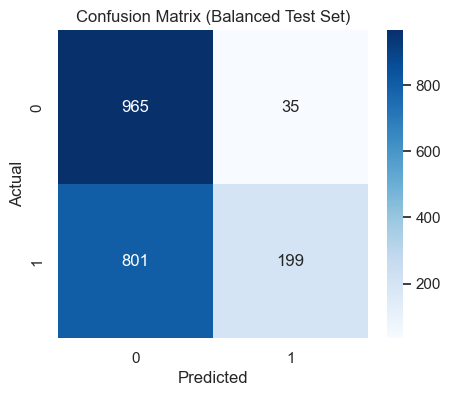

In [13]:
cm_balanced = confusion_matrix(
    y_test_balanced,
    y_pred_balanced
)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_balanced,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Balanced Test Set)")
plt.show()

In [14]:
from imblearn.over_sampling import RandomOverSampler

df_balanced = prep.df.copy()

X = df_balanced.drop("Exited", axis=1)
y = df_balanced["Exited"]

ros = RandomOverSampler(
    sampling_strategy=1.0,
    random_state=42
)

X_balanced, y_balanced = ros.fit_resample(X, y)

print(pd.Series(y_balanced).value_counts())

Exited
1    7963
0    7963
Name: count, dtype: int64


In [15]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_balanced,
    y_balanced,
    test_size=0.20,
    random_state=42,
    stratify=y_balanced
)

print(y_test_b.value_counts())

Exited
0    1593
1    1593
Name: count, dtype: int64


In [16]:
scaler_b = StandardScaler()

X_train_b_scaled = scaler_b.fit_transform(X_train_b)
X_test_b_scaled = scaler_b.transform(X_test_b)

In [17]:
model_b = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model_b.fit(
    X_train_b_scaled,
    y_train_b
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [18]:
y_pred_b = model_b.predict(X_test_b_scaled)

y_prob_b = model_b.predict_proba(
    X_test_b_scaled
)[:,1]

In [19]:
print(classification_report(
    y_test_b,
    y_pred_b
))

cm_b = confusion_matrix(
    y_test_b,
    y_pred_b
)

display(pd.DataFrame(cm_b))

              precision    recall  f1-score   support

           0       0.69      0.72      0.70      1593
           1       0.70      0.67      0.69      1593

    accuracy                           0.69      3186
   macro avg       0.69      0.69      0.69      3186
weighted avg       0.69      0.69      0.69      3186



,0,1
0,1142,451
1,522,1071


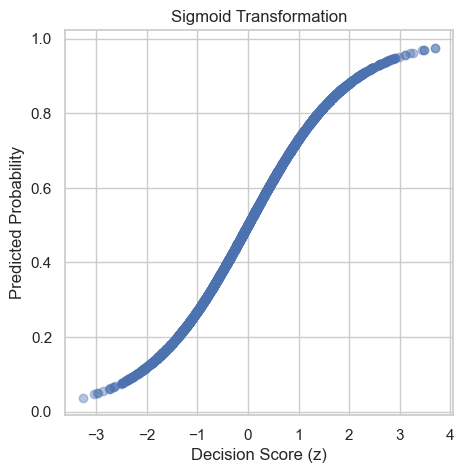

In [20]:
z_score_b = model_b.decision_function(
    X_test_b_scaled
)

plt.figure(figsize=(5,5))

plt.scatter(
    z_score_b,
    y_prob_b,
    alpha=0.4
)

plt.title("Sigmoid Transformation")
plt.xlabel("Decision Score (z)")
plt.ylabel("Predicted Probability")

plt.grid(True)

plt.show()

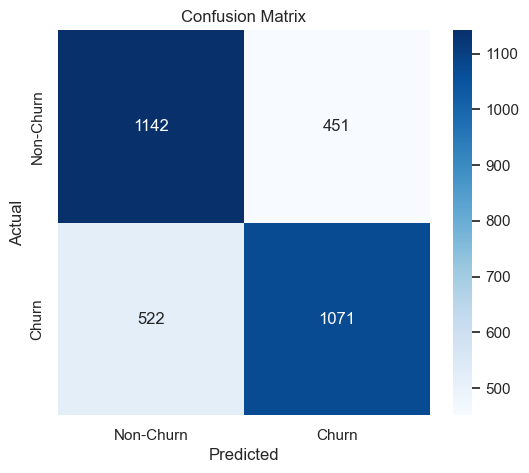

In [21]:
from sklearn.metrics import confusion_matrix

cm_b = confusion_matrix(
    y_test_b,
    y_pred_b
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_b,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Churn","Churn"],
    yticklabels=["Non-Churn","Churn"]
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

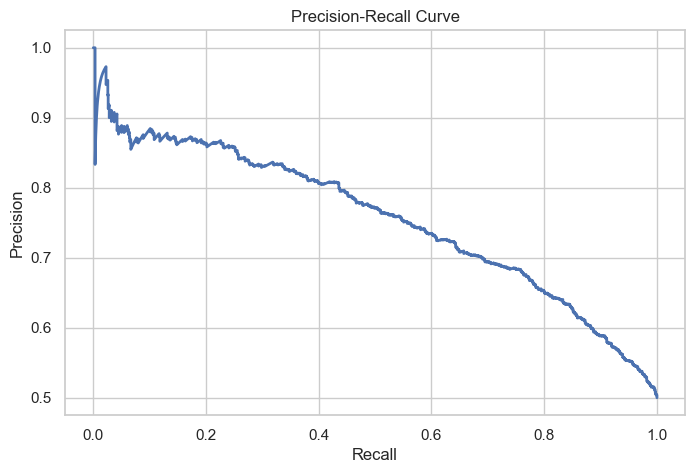

In [22]:
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, _ = precision_recall_curve(
    y_test_b,
    y_prob_b
)

plt.figure(figsize=(8,5))

plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.grid(True)

plt.show()

In [23]:
coef_df_b = pd.DataFrame({

    "Feature": X_train_b.columns,

    "Coefficient": model_b.coef_[0]

})

coef_df_b["Importance"] = coef_df_b["Coefficient"].abs()

coef_df_b = coef_df_b.sort_values(
    by="Importance",
    ascending=False
)

display(coef_df_b)

,Feature,Coefficient,Importance
1,Age,0.835531,0.835531
6,IsActiveMember,-0.461522,0.461522
8,Geography_Germany,0.360946,0.360946
10,Gender_Male,-0.253054,0.253054
3,Balance,0.179989,0.179989
0,CreditScore,-0.099346,0.099346
4,NumOfProducts,-0.065473,0.065473
7,EstimatedSalary,0.036077,0.036077
5,HasCrCard,-0.031676,0.031676
2,Tenure,-0.023238,0.023238


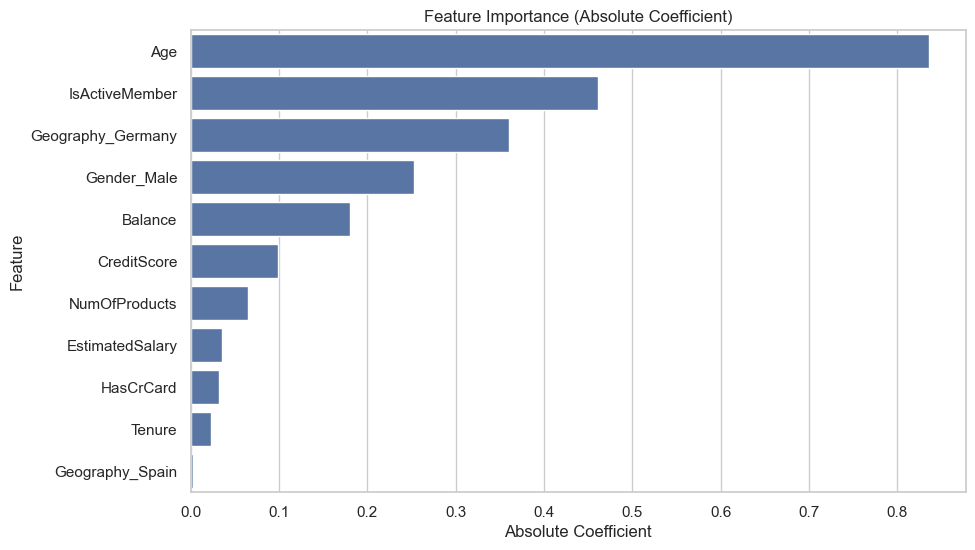

In [24]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=coef_df_b,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance (Absolute Coefficient)")

plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")

plt.show()

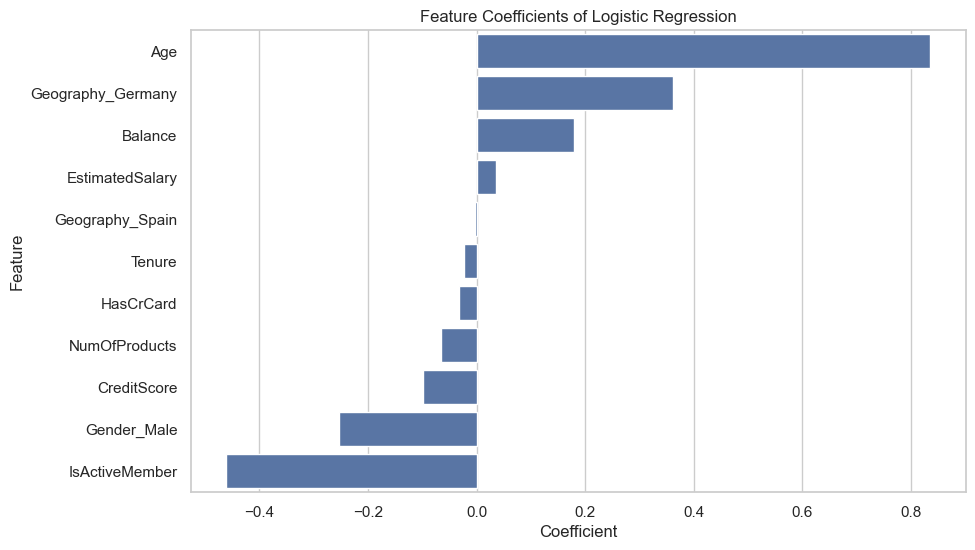

In [25]:
coef_plot = pd.DataFrame({

    "Feature": X_train_b.columns,

    "Coefficient": model_b.coef_[0]

}).sort_values(
    by="Coefficient",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=coef_plot,
    x="Coefficient",
    y="Feature"
)

plt.title("Feature Coefficients of Logistic Regression")

plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

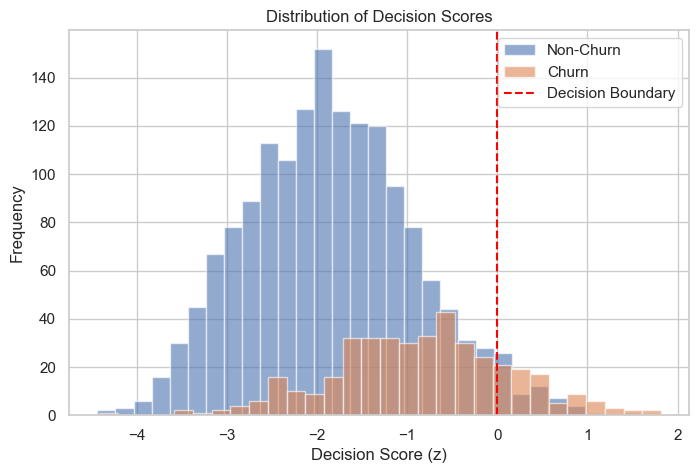

In [26]:
plt.figure(figsize=(8,5))

plt.hist(
    z_score[prep.y_test == 0],
    bins=30,
    alpha=0.6,
    label="Non-Churn"
)

plt.hist(
    z_score[prep.y_test == 1],
    bins=30,
    alpha=0.6,
    label="Churn"
)

plt.axvline(
    0,
    color="red",
    linestyle="--",
    label="Decision Boundary"
)

plt.xlabel("Decision Score (z)")
plt.ylabel("Frequency")
plt.title("Distribution of Decision Scores")
plt.legend()

plt.show()

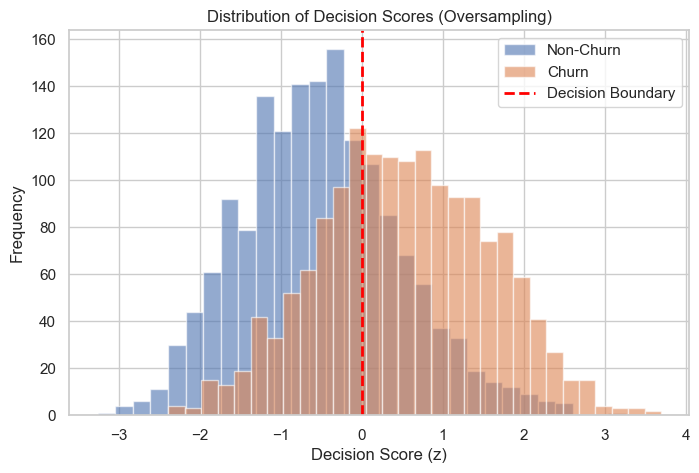

In [27]:
z_score_b = model_b.decision_function(
    X_test_b_scaled
)

plt.figure(figsize=(8,5))

plt.hist(
    z_score_b[y_test_b == 0],
    bins=30,
    alpha=0.6,
    label="Non-Churn"
)

plt.hist(
    z_score_b[y_test_b == 1],
    bins=30,
    alpha=0.6,
    label="Churn"
)

plt.axvline(
    0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Decision Boundary"
)

plt.xlabel("Decision Score (z)")
plt.ylabel("Frequency")
plt.title("Distribution of Decision Scores (Oversampling)")
plt.legend()

plt.grid(True)

plt.show()

In [28]:
decision_score_over = pd.DataFrame({

    "Decision Score": z_score_b,

    "Probability": y_prob_b,

    "Prediction": y_pred_b,

    "Actual": y_test_b.reset_index(drop=True)

})

display(decision_score_over.head(20))

,Decision Score,Probability,Prediction,Actual
0,0.202299,0.550403,1,0
1,1.420932,0.805485,1,1
2,-0.275526,0.431551,0,0
3,-0.579298,0.359094,0,0
4,-0.395571,0.402377,0,0
5,2.767488,0.940893,1,1
6,1.147217,0.759002,1,1
7,-0.723737,0.326571,0,1
8,1.727088,0.849040,1,1
9,-0.436422,0.392594,0,1


In [29]:
model.intercept()

np.float64(-1.6459168487578435)

In [30]:
model_b.intercept_[0]

np.float64(0.01540958806491438)

In [31]:
comparison_df = pd.DataFrame({

    "Feature": X_train_b.columns,

    "Coefficient": model_b.coef_[0]

})

comparison_df["Importance"] = comparison_df["Coefficient"].abs()

comparison_df["Odds Ratio"] = np.exp(
    comparison_df["Coefficient"]
)

comparison_df["Direction"] = comparison_df["Coefficient"].apply(
    lambda x: "Positive (+)" if x > 0 else "Negative (-)"
)

comparison_df = comparison_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

display(comparison_df)

,Feature,Coefficient,Importance,Odds Ratio,Direction
0,Age,0.835531,0.835531,2.306038,Positive (+)
1,IsActiveMember,-0.461522,0.461522,0.630324,Negative (-)
2,Geography_Germany,0.360946,0.360946,1.434686,Positive (+)
3,Gender_Male,-0.253054,0.253054,0.776426,Negative (-)
4,Balance,0.179989,0.179989,1.197205,Positive (+)
5,CreditScore,-0.099346,0.099346,0.905430,Negative (-)
6,NumOfProducts,-0.065473,0.065473,0.936624,Negative (-)
7,EstimatedSalary,0.036077,0.036077,1.036736,Positive (+)
8,HasCrCard,-0.031676,0.031676,0.968821,Negative (-)
9,Tenure,-0.023238,0.023238,0.977030,Negative (-)


In [33]:
print(list(X.columns))

['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']


In [35]:
import joblib

feature_names = joblib.load(r"C:\kuliah\tubes STD & Algo\deployment_model\feature_names.pkl")
print(feature_names)

['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']
